# PTQ + results viewer

Loads the float `.keras` from `train.ipynb`, runs PTQ, and writes:
- `models/<collection>/<run>.tflite`
- `results/<collection>/<run>.json` + `.npz` (metrics, deltas, curves, raw scores)

Re-run the PTQ cell to explore quantization knobs without retraining; every display below re-renders from the live `cmp`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os
import pyrootutils

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator='pyproject.toml',
    pythonpath=True,
    dotenv=True,
)

## Parameters

In [3]:
import json

COLLECTION = 'task_s3_49_2_r50'
BUILD_MODEL = 'mel_cnn'

N_REPRESENTATIVE = 100  # PTQ calibration size

MODEL_PATH = ROOT / 'models' / COLLECTION / f'{BUILD_MODEL}.keras'
TFLITE_PATH = MODEL_PATH.with_suffix('.tflite')
TRAIN_JSON = MODEL_PATH.with_suffix('.train.json')
RESULTS_FILE = ROOT / 'results' / COLLECTION / f'{BUILD_MODEL}.json'

assert MODEL_PATH.exists(), f'missing trained model: {MODEL_PATH}'
assert TRAIN_JSON.exists(), f'missing train sidecar: {TRAIN_JSON} (re-run train.ipynb)'

train_meta = json.loads(TRAIN_JSON.read_text())
BATCH_SIZE = int(train_meta['batch_size'])
SEED = int(train_meta['seed'])
print(f'KERAS  : {MODEL_PATH}')
print(f'TFLITE : {TFLITE_PATH}   exists={TFLITE_PATH.exists()}')
print(f'JSON   : {RESULTS_FILE}')
print(f'train  : batch_size={BATCH_SIZE}  seed={SEED}  epochs_trained={train_meta.get("epochs_trained")}')

KERAS  : /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50/mel_cnn.keras
TFLITE : /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50/mel_cnn.tflite   exists=True
JSON   : /home/nathan/Documents/multi-chirp/results/task_s3_49_2_r50/mel_cnn.json
train  : batch_size=32  seed=42  epochs_trained=54


## Load dataset + float model

Val feeds PTQ calibration; test feeds float-vs-INT8 evaluation.

In [4]:
import logging
import warnings

import numpy as np
import tensorflow as tf

tf.get_logger().setLevel('ERROR')
logging.getLogger('absl').setLevel('ERROR')
warnings.filterwarnings('ignore', message='.*AudioResample.*')

from building.scaling import (
    build_dataset_from_catalog,
    load_dataset_catalog,
    model_factory,
)
from building.models import input_repr_for
from building.models.bake import bake_model
from building.models import model_eval as M
from building import results_io as R

catalog = load_dataset_catalog(COLLECTION)
non_target_idx = catalog.class_names.index('non_target')
target_idxs = [i for i, n in enumerate(catalog.class_names) if n != 'non_target']
final_labels = [catalog.class_names[i] for i in target_idxs] + ['non_target']
n_classes = len(final_labels)

input_repr = input_repr_for(BUILD_MODEL)
rng = np.random.default_rng(SEED)
val_ds, _ = build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split='val', input_repr=input_repr, augment=False,
)
test_ds, _ = build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split='test', input_repr=input_repr, augment=False,
)

model = model_factory(BUILD_MODEL)(n_classes)
model.load_weights(MODEL_PATH)
print(f'Rebuilt {BUILD_MODEL} ({n_classes} classes) from {MODEL_PATH}')
print(f'final label order  : {final_labels}')

Rebuilt mel_cnn (4 classes) from /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50/mel_cnn.keras
final label order  : ['Emberiza_calandra', 'Hippolais_polyglotta', 'Regulus_ignicapilla', 'non_target']


/home/nathan/Documents/multi-chirp/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Post-training quantization

Bakes the float model to INT8 `.tflite`, calibrated on `val_ds`.

In [5]:
tflite_stats = bake_model(model, val_ds, TFLITE_PATH, n_representative=N_REPRESENTATIVE)
print(f'Wrote INT8 .tflite → {TFLITE_PATH}')

Saved artifact at '/tmp/tmp6r_hf8f1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 184, 80, 1), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(1, 4), dtype=tf.float32, name=None)
Captures:
  138107951348432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138107951349584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138107951348816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138107951349200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138107951348240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138107951349392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138107952595408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138107952595600: TensorSpec(shape=(), dtype=tf.resource, name=None)
Baked INT8 TFLite -> /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50/mel_cnn.tflite
  flash (weights)  :     25.2 KB
  est. MFLOPs      :    0.349
  input shape/d

W0000 00:00:1779893441.101435 3817206 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1779893441.101744 3817206 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## Evaluate float vs INT8 on the test set

In [6]:
cmp = M.compare_float_vs_quantized(
    model, TFLITE_PATH, test_ds, final_labels,
    threshold_mode='best_f2', threshold_tuning_ds=val_ds,
    non_target_names=['non_target'],
)
float_eval = cmp.float_eval
quant_eval = cmp.quant_eval
label_names = list(quant_eval.label_names)

y_true = float_eval.y_true
test_loss_float = float(tf.keras.losses.BinaryCrossentropy()(y_true, float_eval.y_score).numpy())
test_loss_quant = float(tf.keras.losses.BinaryCrossentropy()(y_true, quant_eval.y_score).numpy())
qe = quant_eval
print(
    f'INT8 macro-targets — '
    f'precision={qe.macro_precision_targets:.4f}  '
    f'recall={qe.macro_recall_targets:.4f}  '
    f'F1={qe.macro_f1_targets:.4f}  '
    f'F2={qe.macro_f2_targets:.4f}  '
    f'AUC={qe.macro_auc_targets:.4f}'
)
print(f'loss   float={test_loss_float:.4f}   int8={test_loss_quant:.4f}   Δ={test_loss_quant - test_loss_float:+.4f}')
print()
print('per-species F2-optimal thresholds (tuned on val, INT8):')
for name in label_names:
    if name == 'non_target':
        continue
    print(f'  {name:<28s} thr={quant_eval.per_class[name].threshold:.3f}')
print()
M.print_summary(quant_eval)

INT8 macro-targets — precision=0.8704  recall=0.9692  F1=0.9169  F2=0.9475  AUC=0.9940
loss   float=0.1063   int8=0.1096   Δ=+0.0034

per-species F2-optimal thresholds (tuned on val, INT8):
  Emberiza_calandra            thr=0.402
  Hippolais_polyglotta         thr=0.434
  Regulus_ignicapilla          thr=0.500

=== TFLITE evaluation ===
  threshold mode    : best_f2
  top-1 accuracy    : 0.9216
  subset accuracy   : 0.8645
  macro precision   : 0.8735
  macro recall      : 0.9688
  macro F1          : 0.9185
  macro F2          : 0.9480
  macro AUC         : 0.9913
  avg inference (ms): 0.398
  flash (weights)   : 25.2 KB
  est. MFLOPs       : 0.349


## Save record (json + npz)

`.json` holds metrics + deltas + sampled curves; `.npz` holds raw `y_true`, `y_score_float`, `y_score_quant`, per-class ROC and threshold-sweep arrays.

In [7]:
record = R.RunRecord.from_comparison(
    cmp,
    non_target_names=['non_target'],
    tflite_stats=tflite_stats,
    losses=(test_loss_float, test_loss_quant),
    collection=COLLECTION,
    run_name=BUILD_MODEL,
    build_model=BUILD_MODEL,
    model_path=str(MODEL_PATH),
    tflite_path=str(TFLITE_PATH),
    hyperparams={**train_meta, 'input_repr': input_repr, 'n_representative': N_REPRESENTATIVE},
)
record.save(RESULTS_FILE)
meta = record.model_dump(mode='json', by_alias=True)
print(f'Wrote JSON : {RESULTS_FILE}')
print(f'Wrote NPZ  : {RESULTS_FILE.with_suffix(".npz")}')
if meta.get('tflite_stats'):
    s = meta['tflite_stats']
    print(f"\nINT8 footprint: flash={s['model_size_kb']:.1f} KB  "
          f"arena={s.get('arena_size_kb')} KB  MFLOPs={s['flops_mflops']:.3f}")

Wrote JSON : /home/nathan/Documents/multi-chirp/results/task_s3_49_2_r50/mel_cnn.json
Wrote NPZ  : /home/nathan/Documents/multi-chirp/results/task_s3_49_2_r50/mel_cnn.npz

INT8 footprint: flash=25.2 KB  arena=None KB  MFLOPs=0.349


## Per-species metrics (quantized)

`non_target` is shown in the table but excluded from the target-only macro.

In [8]:
tbl = M.per_class_table(quant_eval)
tbl_targets = tbl[tbl['class'] != 'non_target']
display(tbl_targets.style.format(precision=4).set_caption('Quantized per-species'))
if quant_eval.macro_f1_targets is not None:
    print(
        f'Macro (targets only) — precision={quant_eval.macro_precision_targets:.4f}  '
        f'recall={quant_eval.macro_recall_targets:.4f}  '
        f'F1={quant_eval.macro_f1_targets:.4f}  '
        f'F2={quant_eval.macro_f2_targets:.4f}  '
        f'AUC={quant_eval.macro_auc_targets:.4f}'
    )

,class,support,threshold,precision,recall,f1,f2,auc
0,Emberiza_calandra,1609,0.4023,0.8917,0.9720,0.9301,0.9548,0.9956
1,Hippolais_polyglotta,1503,0.4336,0.8274,0.9667,0.8917,0.9352,0.9906
2,Regulus_ignicapilla,1639,0.5000,0.8921,0.9689,0.9289,0.9525,0.9958


Macro (targets only) — precision=0.8704  recall=0.9692  F1=0.9169  F2=0.9475  AUC=0.9940


## Metric-vs-threshold sweep (paper Fig. 5 style, quantized)

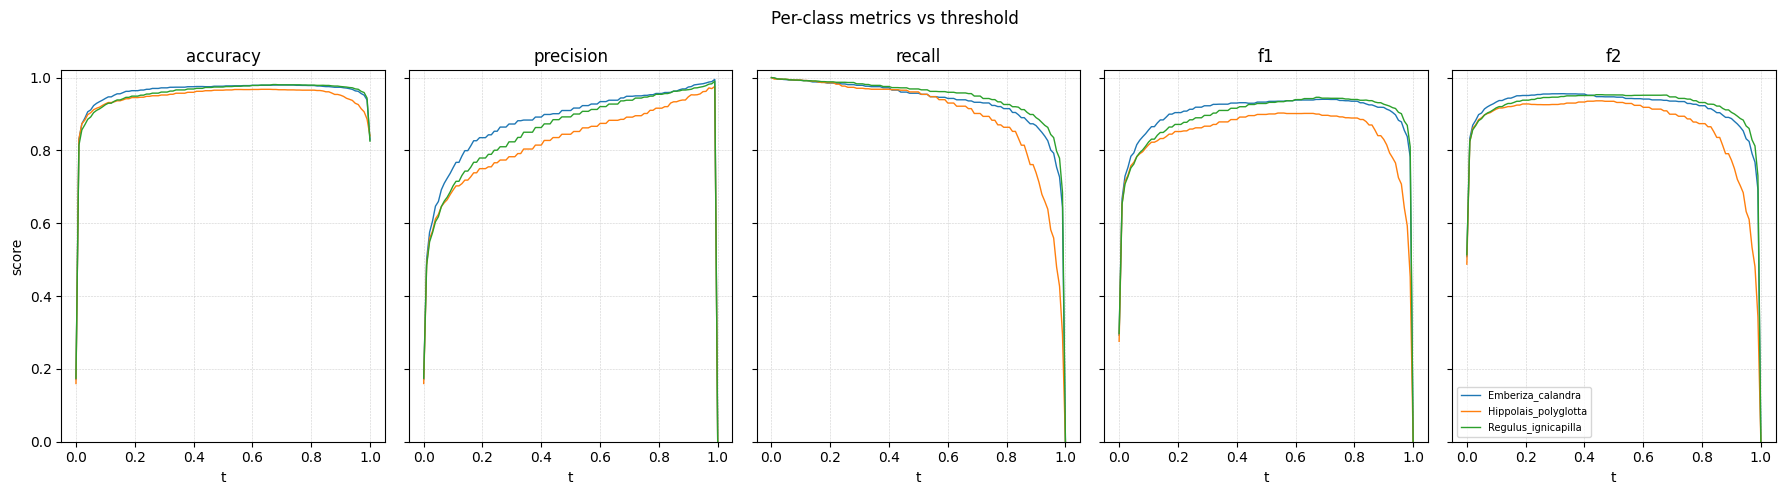

In [9]:
from matplotlib import pyplot as plt
fig = M.plot_metric_sweep_panel(quant_eval, target_only=True)
plt.show()

## ROC per species (quantized) and AUC

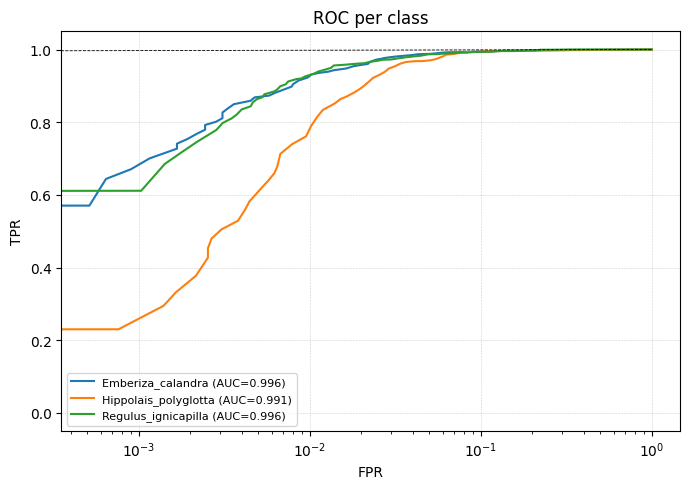

  Emberiza_calandra            AUC=0.9956
  Hippolais_polyglotta         AUC=0.9906
  Regulus_ignicapilla          AUC=0.9958


In [10]:
fig = M.plot_roc(quant_eval, target_only=True)
plt.show()
for name, mclass in quant_eval.per_class.items():
    if name == 'non_target':
        continue
    print(f'  {name:<28s} AUC={mclass.auc:.4f}' if mclass.auc is not None else f'  {name:<28s} n/a')

## Float vs INT8 comparison

,class,support,f1_float,f1_int8,df1,f2_float,f2_int8,df2,prec_float,prec_int8,rec_float,rec_int8
0,Emberiza_calandra,1609,0.928800,0.930100,0.001300,0.954600,0.954800,0.000200,0.888700,0.891700,0.972700,0.972000
1,Hippolais_polyglotta,1503,0.892400,0.891700,-0.000700,0.934800,0.935200,0.000400,0.829600,0.827400,0.965400,0.966700
2,Regulus_ignicapilla,1639,0.925900,0.928900,0.003000,0.951200,0.952500,0.001300,0.886700,0.892100,0.968900,0.968900
3,non_target,4646,0.920700,0.923300,0.002600,0.949100,0.949400,0.000400,0.876900,0.882800,0.969000,0.967700
4,MACRO,9397,0.916900,0.918500,0.001600,0.947400,0.948000,0.000600,0.870500,0.873500,0.969000,0.968800


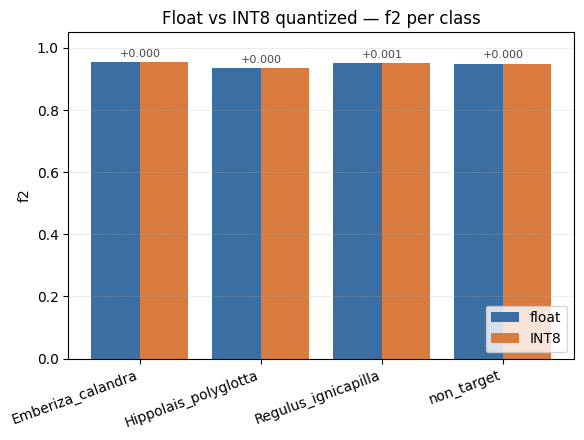

metric                    float       INT8      delta
----------------------------------------------------
top-1 accuracy           0.9237     0.9216    -0.0021
subset accuracy          0.8602     0.8645    +0.0044
macro precision          0.8705     0.8735    +0.0030
macro recall             0.9690     0.9688    -0.0001
macro F1                 0.9169     0.9185    +0.0016
macro F2                 0.9474     0.9480    +0.0006
macro AUC                0.9917     0.9913    -0.0004
avg inference ms         0.5204     0.3976    -0.1228
----------------------------------------------------
flash (weights) KB                    25.2
MFLOPs (est.)                        0.349


In [11]:
display(M.comparison_table(cmp).style.set_caption('Float vs INT8 per-class'))
fig = M.plot_quantization_drop(cmp, metric='f2')
plt.show()
M.print_comparison(cmp)

## Prediction rates by true class (quantized)

Diagonal = recall. Rows can sum past 1 since predictions are independent (multi-label sigmoid).

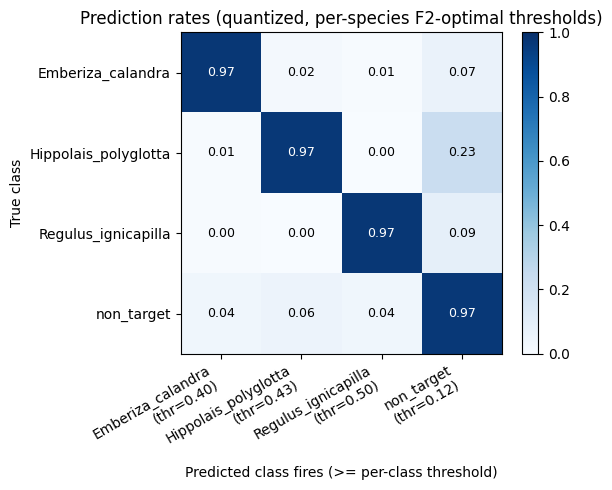

In [12]:
thr_per_class = np.array(
    [quant_eval.per_class[n].threshold for n in label_names], dtype=np.float64
)
y_true = quant_eval.y_true
y_score = quant_eval.y_score
y_true_bin = (y_true >= 0.5).astype(np.int32)
y_pred_bin = (y_score >= thr_per_class[None, :]).astype(np.int32)

rates = np.zeros((len(label_names), len(label_names)), dtype=np.float64)
for i in range(len(label_names)):
    mask = y_true_bin[:, i] == 1
    if mask.any():
        rates[i] = y_pred_bin[mask].mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(rates, cmap='Blues', vmin=0, vmax=1)
xticklabels = [f'{n}\n(thr={t:.2f})' for n, t in zip(label_names, thr_per_class)]
ax.set_xticks(range(len(label_names)))
ax.set_xticklabels(xticklabels, rotation=30, ha='right')
ax.set_yticks(range(len(label_names)))
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted class fires (>= per-class threshold)')
ax.set_ylabel('True class')
ax.set_title('Prediction rates (quantized, per-species F2-optimal thresholds)')
for i in range(rates.shape[0]):
    for j in range(rates.shape[1]):
        ax.text(j, i, f'{rates[i, j]:.2f}',
                ha='center', va='center',
                color='white' if rates[i, j] > 0.5 else 'black', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## Float vs INT8, delta table

In [13]:
deltas = meta.get('deltas', {})
print('macro_targets deltas (INT8 - float):')
for k, v in (deltas.get('macro_targets') or {}).items():
    print(f'  {k:<12s} {v:+.4f}' if v is not None else f'  {k:<12s} n/a')
print('\nper-class F2 delta:')
for name, d in (deltas.get('per_class') or {}).items():
    if name == 'non_target':
        continue
    if d.get('f2') is not None:
        print(f'  {name:<28s} {d["f2"]:+.4f}')

macro_targets deltas (INT8 - float):
  precision    +0.0021
  recall       +0.0002
  f1           +0.0012
  f2           +0.0006
  auc          -0.0004

per-class F2 delta:
  Emberiza_calandra            +0.0002
  Hippolais_polyglotta         +0.0004
  Regulus_ignicapilla          +0.0013


## Cache cleanup (optional)

Wipes the waveform cache built when val/test were materialised. Skip while iterating on PTQ knobs.

In [14]:
from building.scaling import cleanup_waveform_cache

cleanup_waveform_cache(COLLECTION)

[cleanup] removed /home/nathan/Documents/multi-chirp/.cache/task_s3_49_2_r50 (12,004.5 MB freed)


## Real-world per-minute evaluation (long XC recordings)

Streams every cached long recording in this area through the INT8 `.tflite`, aggregates 3 s window probs to one row per minute, and joins against the BirdNET ground truth cached by `dataset_build.ipynb`.

For each minute we report:
- **P(bird | model bird)**: when the model says a target species, BirdNET agrees a bird is there.
- **P(correct species | s)**: when the model names a target, that target matches BirdNET.
- **P(miss | BirdNET bird)**: BirdNET heard a bird but the model said nothing.

Configure `LAT/LON/RADIUS_KM` to match the area used in `dataset_build.ipynb`.

In [15]:
from building.geographic_task.long_recordings import (
    evaluate_long_recordings,
    format_stats,
    long_rec_dir,
)

LAT, LON, RADIUS_KM = 48.8566, 2.3522, 50  # must match dataset_build.ipynb
TARGET_SPECIES = [n for n in final_labels if n != 'non_target']

# Reuse the F2-optimal per-species thresholds picked on val.
thr_map = {n: float(quant_eval.per_class[n].threshold) for n in TARGET_SPECIES}

long_dir = long_rec_dir(LAT, LON, RADIUS_KM)
reports, totals = evaluate_long_recordings(
    audio_dir=long_dir,
    tflite_path=TFLITE_PATH,
    label_names=final_labels,
    target_species=TARGET_SPECIES,
    threshold=thr_map,
)

print(f"=== Real-world summary ({len(reports)} recordings) ===")
print(format_stats(totals))

INT8 over long:   0%|          | 0/22 [00:00<?, ?it/s]

ValueError: cannot reshape array of size 48000 into shape (184,80,1)

In [ ]:
import pandas as pd

rows = []
for r in reports:
    s = r.stats
    rows.append(
        {
            "xc_id": r.xc_id,
            "length_min": round(r.length_seconds / 60, 1),
            "minutes": s.n_minutes,
            "model_bird": s.n_model_bird,
            "birdnet_bird": s.n_birdnet_bird,
            "P(bird|model)": s.precision_bird,
            "P(correct|species)": s.correct_species_rate,
            "P(miss|birdnet)": s.miss_rate,
        }
    )
per_rec = pd.DataFrame(rows).sort_values("xc_id").reset_index(drop=True)
per_rec.style.format(
    {"P(bird|model)": "{:.2%}", "P(correct|species)": "{:.2%}", "P(miss|birdnet)": "{:.2%}"},
    na_rep="—",
).set_caption("Per-recording per-minute metrics")

,xc_id,length_min,minutes,model_bird,birdnet_bird,P(bird|model),P(correct|species),P(miss|birdnet)
0,475259,2.200000,3,3,3,100.00%,100.00%,0.00%
1,475261,4.100000,5,3,4,100.00%,100.00%,25.00%
2,535407,1.000000,1,0,1,—,—,100.00%
3,553195,1.400000,2,0,2,—,—,100.00%
4,556796,1.000000,1,0,1,—,—,100.00%
5,556866,2.400000,3,2,3,100.00%,100.00%,33.33%
6,556868,3.000000,3,3,3,100.00%,100.00%,0.00%
7,556870,2.600000,3,2,3,100.00%,100.00%,33.33%
8,556872,3.500000,4,3,4,100.00%,100.00%,25.00%
9,556873,2.400000,3,1,3,100.00%,100.00%,66.67%
